## Simulating Spatial Autocorrelation with RADIAN

In [103]:
import geopandas as gpd



In [104]:

hp = gpd.read_file("geojson/radian_hp.geojson").drop(['id'], axis=1).to_crs(3857)
hp['id'] = hp.index+1
dublin = gpd.read_file("geojson/dublin.geojson").to_crs(3857)
print(hp.head())

   housePrice                         geometry  id
0         499  POINT (-696135.656 7052490.675)   1
1         193   POINT (-695192.112 7043903.99)   2
2         251  POINT (-689711.409 7051948.639)   3
3         389    POINT (-700924.51 7043782.65)   4
4         747  POINT (-702670.556 7048131.367)   5


In [105]:
# Import required packages
import matplotlib as mpl
from matplotlib import colors

%matplotlib inline
mpl.rcParams['figure.figsize'] = (15, 10) #this increases the inline figure size to 15 tall x 10 wide

import seaborn
import pandas as pd
import geopandas as gpd
import pysal
import numpy as np
import mapclassify
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore') # Change settings so that warnings are not displayed

# Loading a few new packages
import contextily as cx
from shapely.geometry import Polygon
import plotly.express as px
import libpysal.weights
import esda
from libpysal import weights
from splot.esda import plot_moran
from splot.esda import moran_scatterplot
from splot.esda import plot_local_autocorrelation
from splot.esda import lisa_cluster
from esda.moran import Moran_Local

In [106]:
xmin,ymin,xmax,ymax =  hp.total_bounds
length = 500
wide = 500

cols = list(np.arange(xmin, xmax + wide, wide))
rows = list(np.arange(ymin, ymax + length, length))

polygons = []
for x in cols[:-1]:
    for y in rows[:-1]:
        polygons.append(Polygon([(x,y), (x+wide, y), (x+wide, y+length), (x, y+length)]))

grid = gpd.GeoDataFrame({'geometry':polygons})

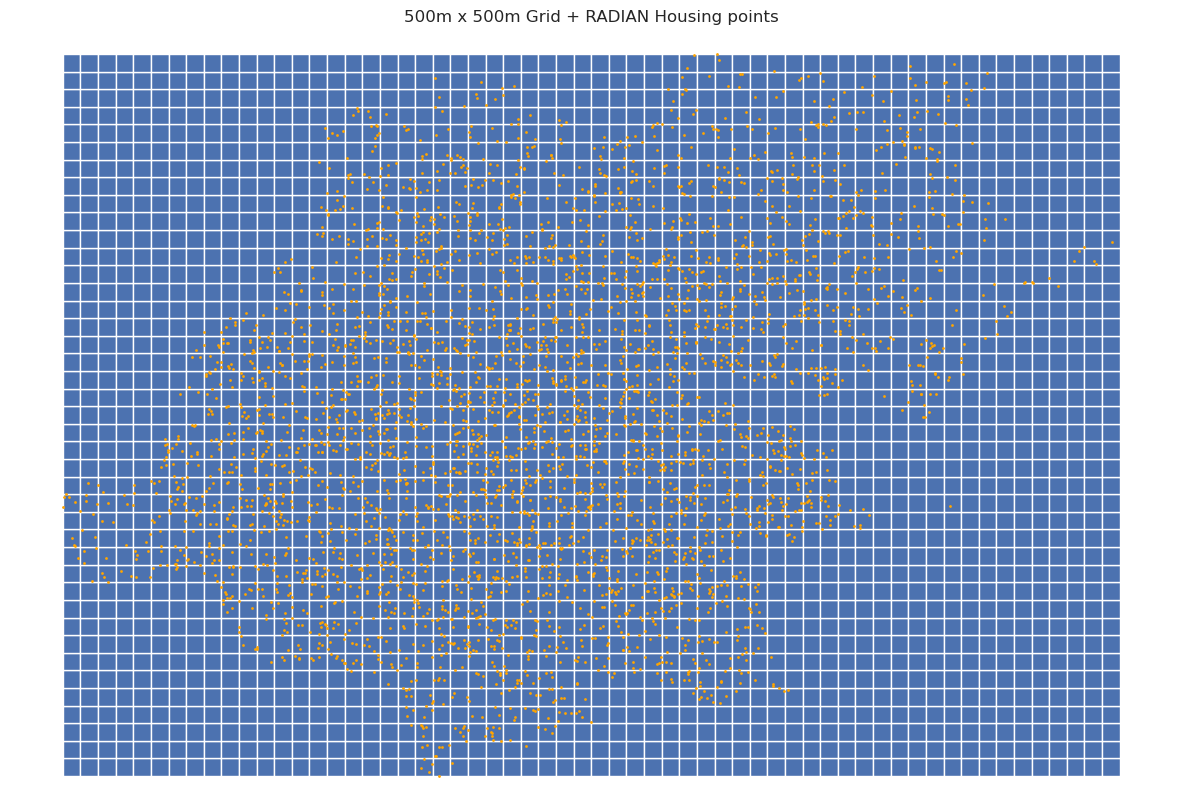

In [107]:
f, ax = plt.subplots(1, figsize=(15, 10)) #Subplots allows you to draw multiple plots in one figure
grid.plot(ax=ax, legend=False, edgecolor='white')
hp.plot(ax=ax, color='orange', markersize=1, alpha=1)
ax.set_axis_off() #Remove axes from plot 
ax.set_title('500m x 500m Grid + RADIAN Housing points') #Plot title text
plt.axis('equal') #Set x and y axes to be equal size
plt.show()

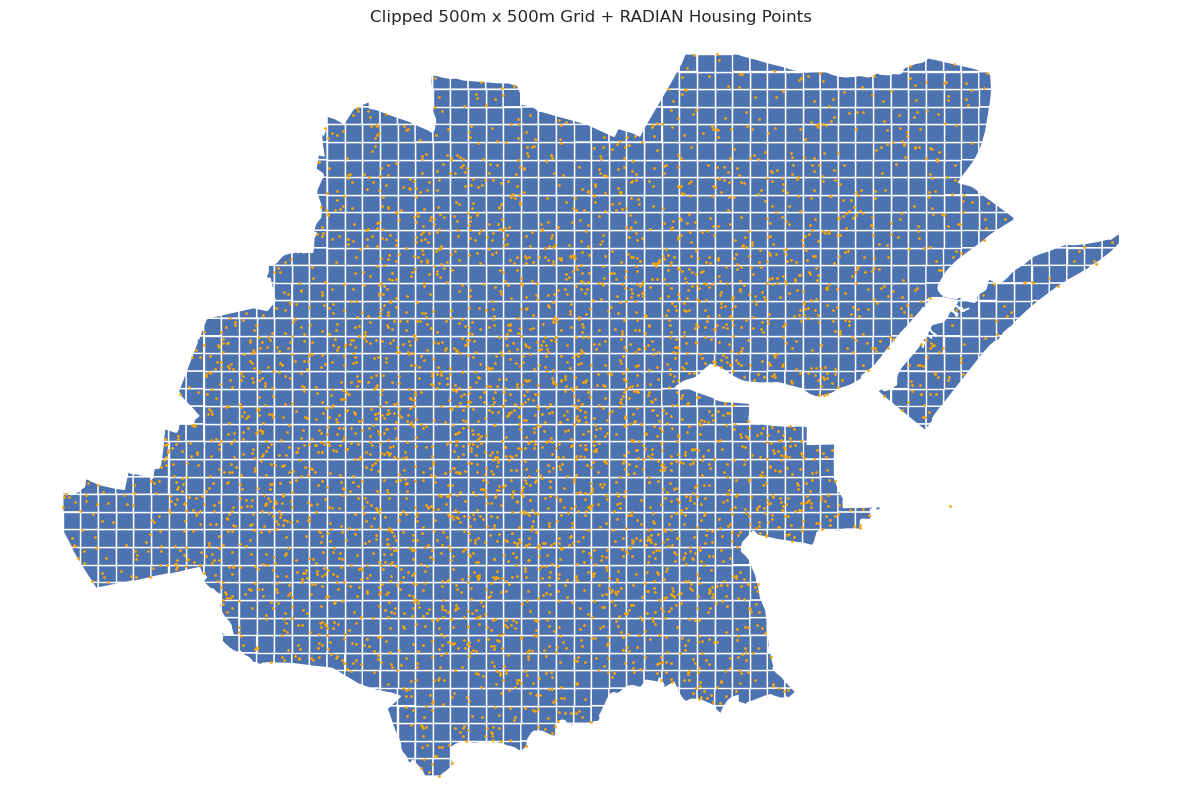

In [108]:
grid_clip = gpd.clip(grid, dublin) #Clip the grid to the extent of the London boroughs GeoJSON

f, ax = plt.subplots(1, figsize=(15, 10)) #Subplots allows you to draw multiple plots in one figure
grid_clip.plot(ax=ax, legend=False, edgecolor='white')
hp.plot(ax=ax, color='orange', markersize=1, alpha=1)
ax.set_axis_off() #Remove axes from plot 
ax.set_title('Clipped 500m x 500m Grid + RADIAN Housing Points') #Plot title text
plt.axis('equal') #Set x and y axes to be equal size
plt.show()

In [109]:
grid_clip['ID2'] = grid_clip.index+1
hp2 = gpd.sjoin(hp,grid_clip)
hp3 = hp2.groupby('ID2').agg({'housePrice':'median','id':'count'})
hp3.columns = ['MedianPrice','House_Count']
hp3 = hp3.reset_index()

grid_clip2 = grid_clip.merge(hp3, how='outer')
grid_clip2['MedianPrice'] = grid_clip2['MedianPrice'].fillna(0) #Fill median house price NAs w/0
grid_clip2['House_Count'] = grid_clip2['House_Count'].fillna(0) #Fill house count NAs w/0
grid_clip2 = grid_clip2.set_crs(epsg=3857)
grid_clip2.to_crs(epsg=4326)

,geometry,ID2,MedianPrice,House_Count
0,"POLYGON ((-6.38121 53.3348, -6.38121 53.33224,...",13,804.0,1.0
1,"POLYGON ((-6.3857 53.33748, -6.38121 53.33748,...",14,239.0,3.0
2,"POLYGON ((-6.3857 53.34016, -6.38121 53.34016,...",15,0.0,0.0
3,"POLYGON ((-6.38121 53.34284, -6.38121 53.34016...",16,653.0,5.0
4,"MULTIPOLYGON (((-6.3857 53.34284, -6.3857 53.3...",17,905.0,1.0
...,...,...,...,...
1478,"POLYGON ((-6.12519 53.37769, -6.1231 53.37769,...",2407,0.0,0.0
1479,"POLYGON ((-6.12519 53.37769, -6.12519 53.38037...",2408,827.5,2.0
1480,"POLYGON ((-6.1207 53.38037, -6.12519 53.38037,...",2409,0.0,0.0
1481,"POLYGON ((-6.1207 53.38037, -6.11719 53.38037,...",2449,0.0,0.0


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


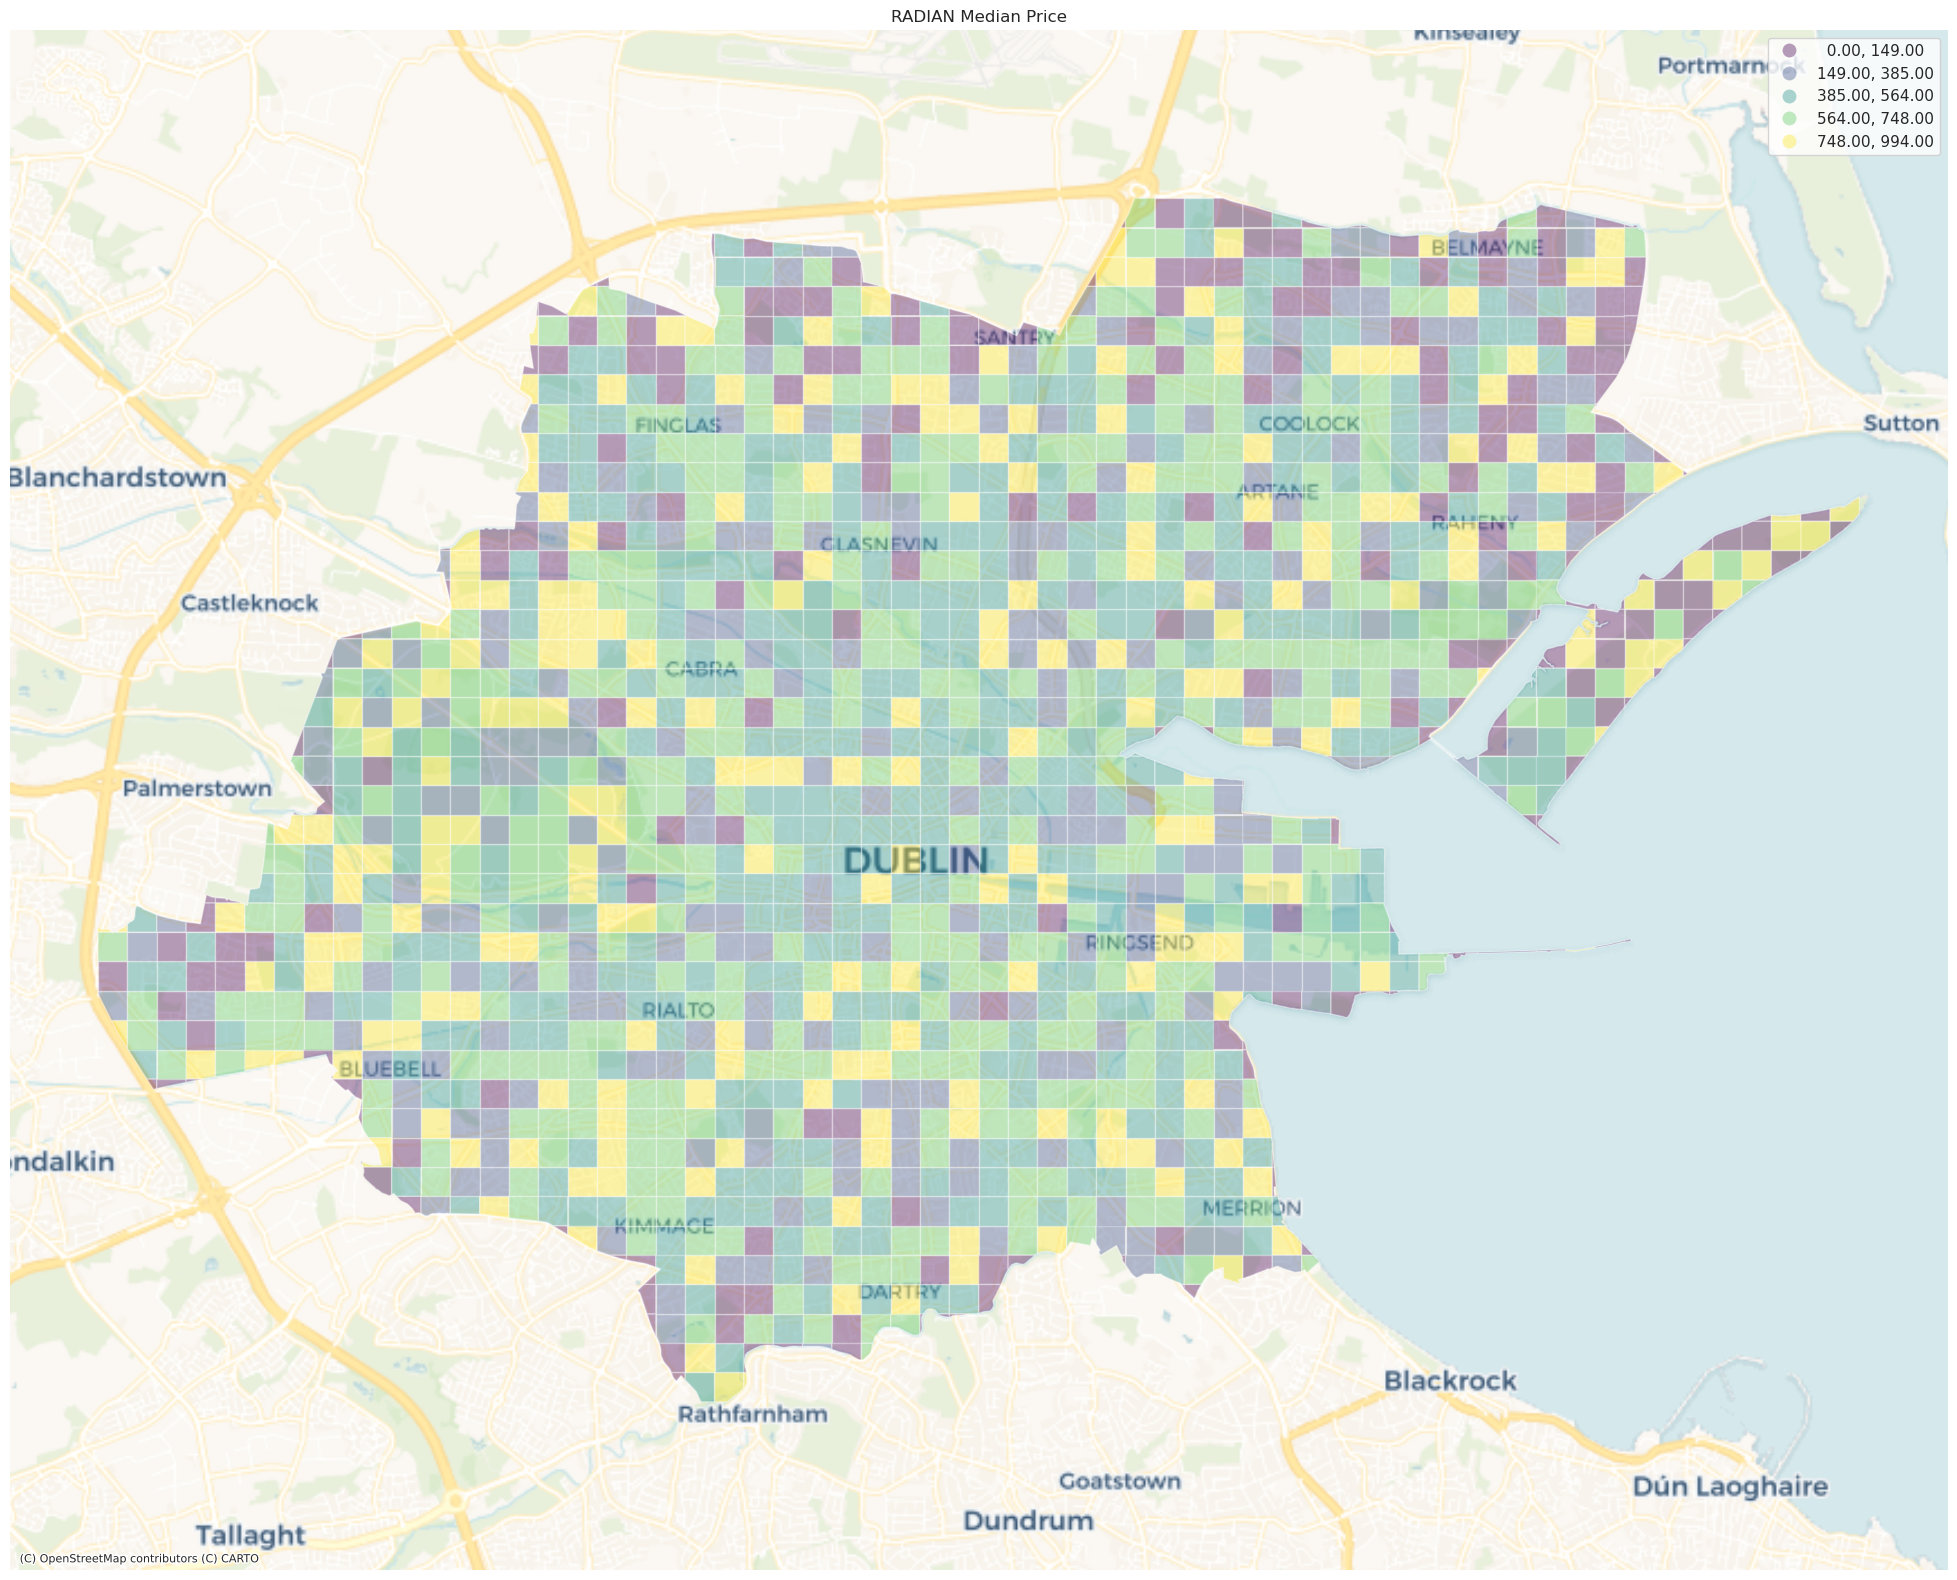

In [110]:
f, ax = plt.subplots(1, figsize=(25, 20)) #Subplots allows you to draw multiple plots in one figure
grid_clip2.to_crs('EPSG:3857').plot(ax=ax, column='MedianPrice', cmap='viridis', legend=True, scheme='FisherJenks', k=5, edgecolor='white', alpha=.38)
ax.set_axis_off() #Remove axes from plot 
ax.set_title('RADIAN Median Price') #Plot title text
plt.axis('equal') #Set x and y axes to be equal size
cx.add_basemap(ax, source=cx.providers.CartoDB.Voyager)

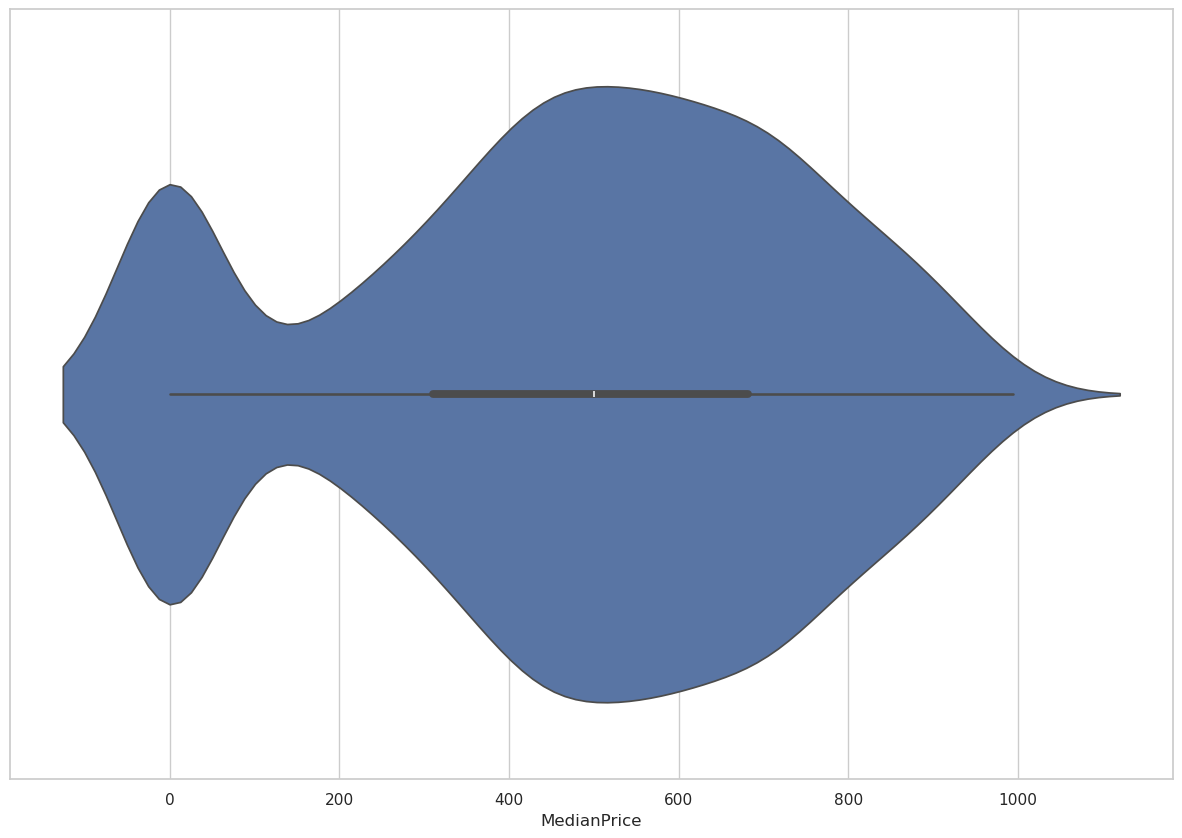

In [111]:
seaborn.set_theme(style="whitegrid")
bx = seaborn.violinplot(x=grid_clip2["MedianPrice"])

In [112]:
# Generate W from the GeoDataFrame
w = weights.Queen.from_dataframe(grid_clip2)
# Row-standardization
w.transform = 'R'

print(w.neighbors)
print(w.weights)
grid_clip2['MedianPrice_lag'] = weights.spatial_lag.lag_spatial(w, grid_clip2['MedianPrice'])


{0: [8, 1, 7], 1: [0, 2, 7, 8, 9], 2: [1, 3, 8, 9, 10], 3: [2, 4, 9, 10, 11], 4: [11, 10, 3], 5: [12, 13, 6], 6: [5, 7, 12, 13, 14], 7: [0, 1, 6, 8, 13, 14, 15], 8: [0, 1, 2, 7, 9, 14, 15, 16], 9: [1, 2, 3, 8, 10, 15, 16, 17], 10: [2, 3, 4, 9, 11, 16, 17, 18], 11: [17, 18, 3, 4, 10], 12: [19, 20, 5, 6, 13], 13: [5, 6, 7, 12, 14, 19, 20, 21], 14: [6, 7, 8, 13, 15, 20, 21, 22], 15: [7, 8, 9, 14, 16, 21, 22, 23], 16: [8, 9, 10, 15, 17, 22, 23, 24], 17: [9, 10, 11, 16, 18, 23, 24, 25], 18: [17, 24, 25, 10, 11], 19: [13, 20, 12], 20: [28, 19, 21, 27, 12, 13, 14], 21: [13, 14, 15, 20, 22, 27, 28, 29], 22: [14, 15, 16, 21, 23, 28, 29, 30], 23: [15, 16, 17, 22, 24, 29, 30, 31], 24: [32, 16, 17, 18, 23, 25, 30, 31], 25: [32, 33, 17, 18, 24, 26, 31], 26: [32, 33, 25], 27: [34, 35, 20, 21, 28], 28: [34, 35, 36, 20, 21, 22, 27, 29], 29: [35, 36, 37, 21, 22, 23, 28, 30], 30: [36, 37, 38, 22, 23, 24, 29, 31], 31: [32, 37, 38, 39, 23, 24, 25, 30], 32: [33, 38, 39, 24, 25, 26, 31], 33: [32, 25, 26], 3

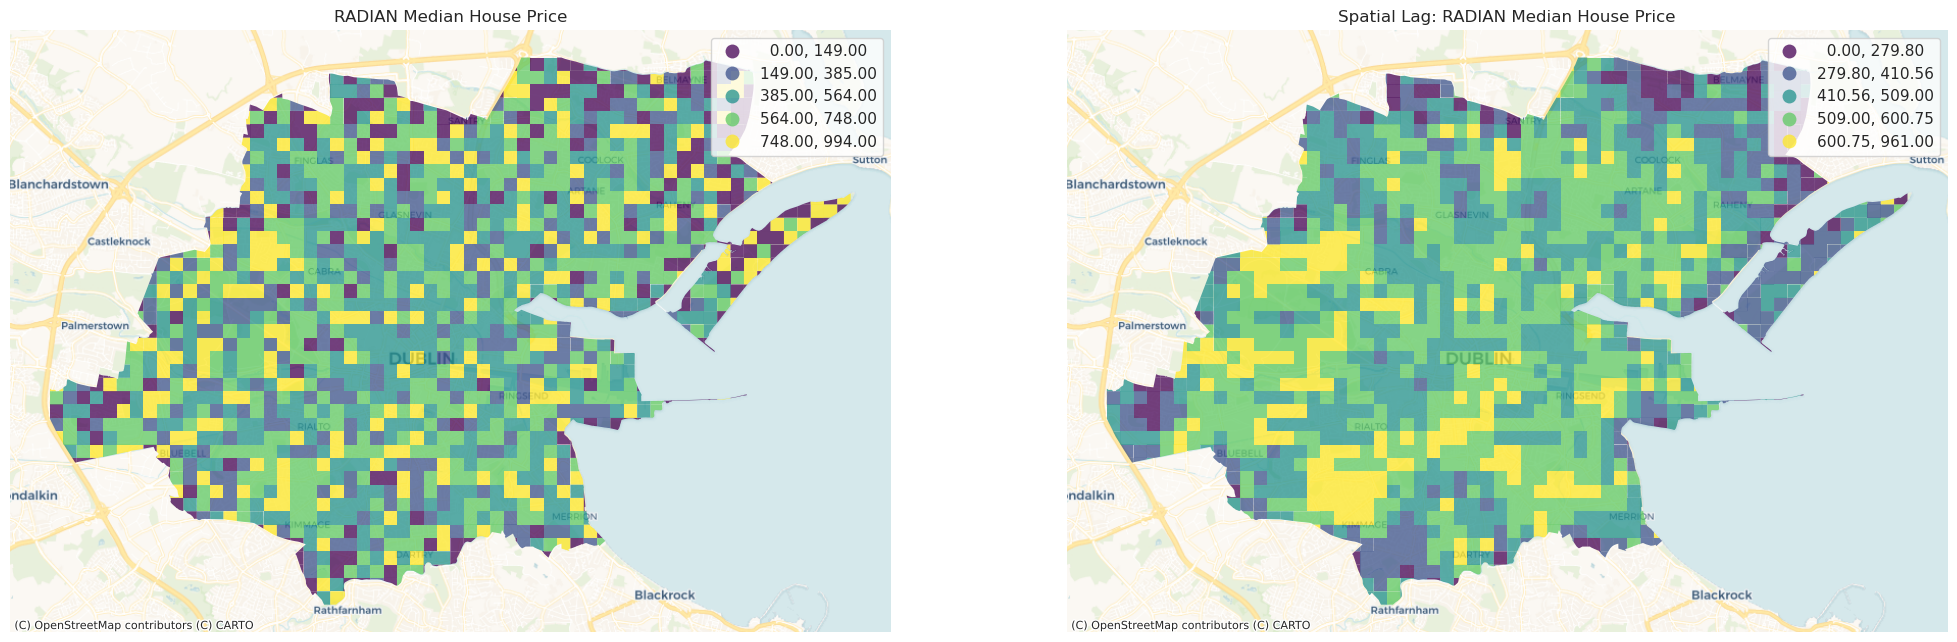

In [113]:
f, axs = plt.subplots(1, 2, figsize=(25, 20))
ax1, ax2 = axs

grid_clip2.to_crs('EPSG:3857').plot(column='MedianPrice', cmap='viridis', scheme='FisherJenks',
        k=5, edgecolor='white', linewidth=0., alpha=0.75, legend=True, ax=ax1)
ax1.set_axis_off()
ax1.set_title("RADIAN Median House Price")
cx.add_basemap(ax1, source=cx.providers.CartoDB.Voyager)

grid_clip2.to_crs('EPSG:3857').plot(column='MedianPrice_lag', cmap='viridis', scheme='FisherJenks',
        k=5, edgecolor='white', linewidth=0., alpha=0.75, legend=True, ax=ax2)
ax2.set_axis_off()
ax2.set_title("Spatial Lag: RADIAN Median House Price")
cx.add_basemap(ax2, source=cx.providers.CartoDB.Voyager)

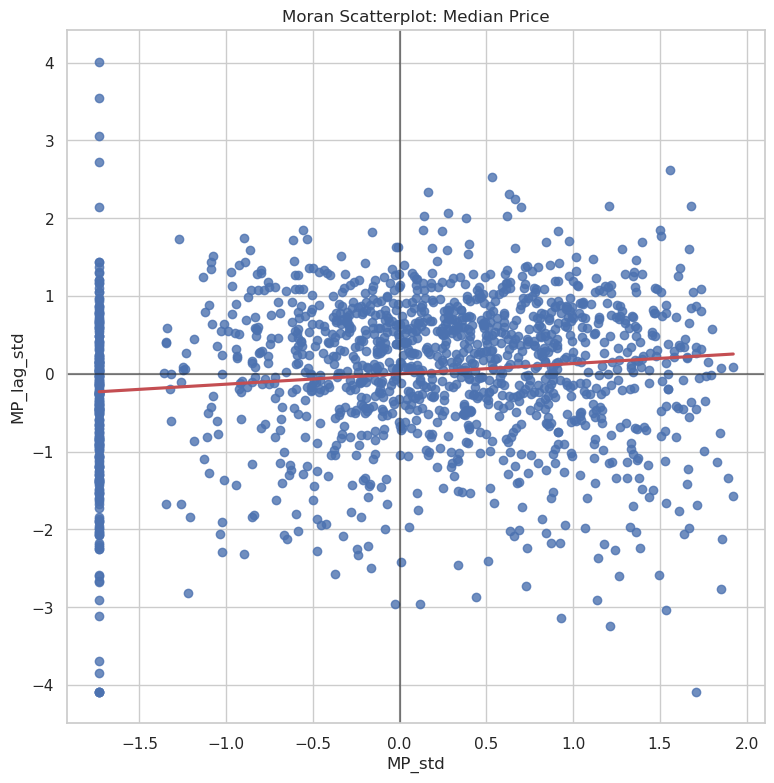

Global Moran's I =  0.05787687073438232


In [114]:
grid_clip2['MP_std'] = ( grid_clip2['MedianPrice'] - grid_clip2['MedianPrice'].mean() )\
                    / grid_clip2['MedianPrice'].std()
grid_clip2['MP_lag_std'] = ( grid_clip2['MedianPrice_lag'] - grid_clip2['MedianPrice_lag'].mean() )\
                    / grid_clip2['MedianPrice_lag'].std()

f, ax = plt.subplots(1, figsize=(9, 9))

seaborn.regplot(x='MP_std', y='MP_lag_std', 
                ci=None, data=grid_clip2, line_kws={'color':'r'})
ax.axvline(0, c='k', alpha=0.5)
ax.axhline(0, c='k', alpha=0.5)
ax.set_title('Moran Scatterplot: Median Price')
plt.show()

w.transform = 'R'
moran = esda.Moran(grid_clip2['MedianPrice'], w)
print("Global Moran's I = ", moran.I)